In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             precision_recall_curve, average_precision_score,
                             f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append('D:/Projects/fraud-detection-shap-aws')
from utils.config_loader import load_config

# Load config and data
config = load_config('D:/Projects/fraud-detection-shap-aws/configs/creditcard_config.json')
df = pd.read_csv('D:/Projects/fraud-detection-shap-aws/data/processed/creditcard_processed.csv')

target = config['target_column']
X = df.drop(target, axis=1)
y = df[target]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Data loaded: {df.shape}")
print(f" Train: {X_train.shape} | Test: {X_test.shape}")
print(f" Fraud in train: {y_train.sum()} | Fraud in test: {y_test.sum()}")

Config loaded: Credit Card Fraud
 Data loaded: (284807, 31)
 Train: (227845, 30) | Test: (56962, 30)
 Fraud in train: 394 | Fraud in test: 98


In [4]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    """Prints full evaluation metrics for any model"""
    print(f"\n{'='*50}")
    print(f"MODEL: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy  : {(y_true == y_pred).mean()*100:.4f}%")
    print(f"Precision : {precision_score(y_true, y_pred)*100:.2f}%")
    print(f"Recall    : {recall_score(y_true, y_pred)*100:.2f}%")
    print(f"F1 Score  : {f1_score(y_true, y_pred)*100:.2f}%")
    if y_prob is not None:
        print(f"ROC-AUC   : {roc_auc_score(y_true, y_prob)*100:.2f}%")
        print(f"PR-AUC    : {average_precision_score(y_true, y_prob)*100:.2f}%")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, 
                                target_names=['Legitimate', 'Fraud']))
    return {
        'model': model_name,
        'accuracy': (y_true == y_pred).mean()*100,
        'precision': precision_score(y_true, y_pred)*100,
        'recall': recall_score(y_true, y_pred)*100,
        'f1': f1_score(y_true, y_pred)*100,
        'pr_auc': average_precision_score(y_true, y_prob)*100 if y_prob is not None else 0
    }

def plot_confusion_matrix(y_true, y_pred, model_name):
    """Plots confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    ax.set_title(f'Confusion Matrix — {model_name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'D:/Projects/fraud-detection-shap-aws/reports/shap_plots/cm_{model_name.replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    fraud_caught = cm[1][1]
    fraud_missed = cm[1][0]
    print(f"Fraud caught  : {fraud_caught}")
    print(f"Fraud missed  : {fraud_missed}")
    print(f"False alarms  : {cm[0][1]}")

print("Helper functions ready")

Helper functions ready



MODEL: Logistic Regression (Baseline — No Fix)
Accuracy  : 99.9140%
Precision : 81.82%
Recall    : 64.29%
F1 Score  : 72.00%
ROC-AUC   : 95.82%
PR-AUC    : 74.02%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.82      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



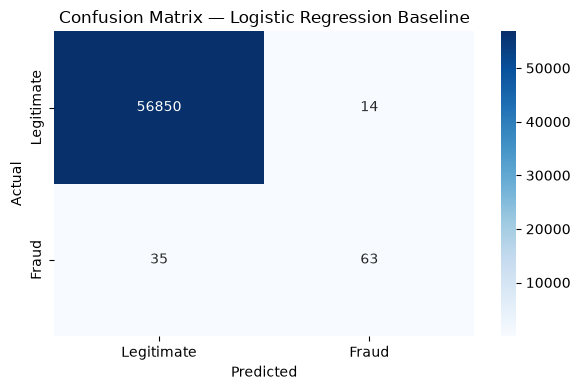

Fraud caught  : 63
Fraud missed  : 35
False alarms  : 14


In [5]:
# Train baseline — no tricks, no SMOTE, nothing
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train, y_train)

y_pred_baseline = lr_baseline.predict(X_test)
y_prob_baseline = lr_baseline.predict_proba(X_test)[:, 1]

# Evaluate
results_baseline = evaluate_model(
    y_test, y_pred_baseline, y_prob_baseline, 
    "Logistic Regression (Baseline — No Fix)"
)

plot_confusion_matrix(y_test, y_pred_baseline, "Logistic Regression Baseline")

In [7]:
print("\n" + "="*55)
print("THE ACCURACY LIE — WHAT 99.9% ACCURACY ACTUALLY MEANS")
print("="*55)

cm = confusion_matrix(y_test, y_pred_baseline)
total_fraud = cm[1][0] + cm[1][1]
caught = cm[1][1]
missed = cm[1][0]

print(f"\nTotal fraud in test set : {total_fraud}")
print(f"Fraud CAUGHT            : {caught}  ")
print(f"Fraud MISSED            : {missed}  ")
print(f"\nAccuracy says           : {results_baseline['accuracy']:.2f}% (GREAT!)")
print(f"Reality says             : {missed} fraudulent transactions were missed")
print(f"\nPR-AUC                  : {results_baseline['pr_auc']:.2f}%")
print(f"→ PR-AUC tells the real story.")
print("="*55)


THE ACCURACY LIE — WHAT 99.9% ACCURACY ACTUALLY MEANS

Total fraud in test set : 98
Fraud CAUGHT            : 63  
Fraud MISSED            : 35  

Accuracy says           : 99.91% (GREAT!)
Reality says             : 35 fraudulent transactions were missed

PR-AUC                  : 74.02%
→ PR-AUC tells the real story.



MODEL: Logistic Regression (class_weight=balanced)
Accuracy  : 97.5475%
Precision : 6.09%
Recall    : 91.84%
F1 Score  : 11.41%
ROC-AUC   : 97.20%
PR-AUC    : 71.89%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



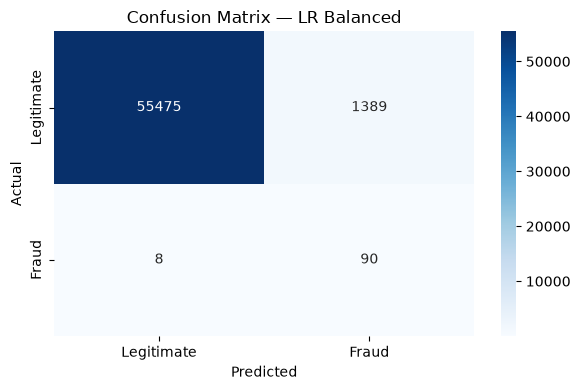

Fraud caught  : 90
Fraud missed  : 8
False alarms  : 1389


In [8]:
# Fix 1 — tell the model fraud matters more
lr_balanced = LogisticRegression(
    class_weight='balanced', 
    random_state=42, 
    max_iter=1000
)
lr_balanced.fit(X_train, y_train)

y_pred_balanced = lr_balanced.predict(X_test)
y_prob_balanced = lr_balanced.predict_proba(X_test)[:, 1]

results_balanced = evaluate_model(
    y_test, y_pred_balanced, y_prob_balanced,
    "Logistic Regression (class_weight=balanced)"
)

plot_confusion_matrix(y_test, y_pred_balanced, "LR Balanced")

Applying SMOTE to training data only...
Before SMOTE — Train fraud: 394, Train legit: 227451
After SMOTE  — Train fraud: 227451, Train legit: 227451
Training set size: 227845 → 454902

 SMOTE applied to training set ONLY
 Test set untouched — no data leakage

MODEL: Logistic Regression (SMOTE)
Accuracy  : 97.4685%
Precision : 5.91%
Recall    : 91.84%
F1 Score  : 11.10%
ROC-AUC   : 97.12%
PR-AUC    : 72.35%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



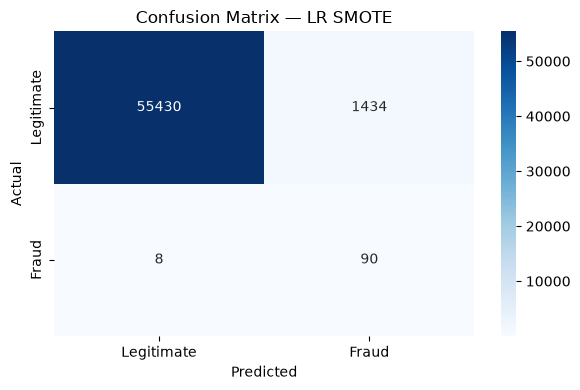

Fraud caught  : 90
Fraud missed  : 8
False alarms  : 1434


In [9]:
# SMOTE — ONLY on training data, NEVER test data
print("Applying SMOTE to training data only...")
print(f"Before SMOTE — Train fraud: {y_train.sum()}, Train legit: {(y_train==0).sum()}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  — Train fraud: {y_train_smote.sum()}, Train legit: {(y_train_smote==0).sum()}")
print(f"Training set size: {len(X_train)} → {len(X_train_smote)}")
print("\n SMOTE applied to training set ONLY")
print(" Test set untouched — no data leakage")

# Train on SMOTE data
lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test)
y_prob_smote = lr_smote.predict_proba(X_test)[:, 1]

results_smote = evaluate_model(
    y_test, y_pred_smote, y_prob_smote,
    "Logistic Regression (SMOTE)"
)

plot_confusion_matrix(y_test, y_pred_smote, "LR SMOTE")

Training Isolation Forest — unsupervised anomaly detection...
This model has NEVER seen the Class label during training


MODEL: Isolation Forest (Unsupervised)
Accuracy  : 99.7560%
Precision : 30.48%
Recall    : 32.65%
F1 Score  : 31.53%
ROC-AUC   : 95.36%
PR-AUC    : 19.16%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.30      0.33      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962



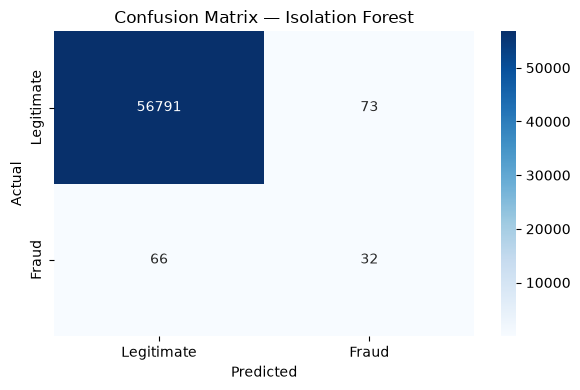

Fraud caught  : 32
Fraud missed  : 66
False alarms  : 73

 Key insight: Isolation Forest caught fraud without ever seeing a single fraud label during training


In [10]:
print("Training Isolation Forest — unsupervised anomaly detection...")
print("This model has NEVER seen the Class label during training\n")

# Auto-detect contamination from config
fraud_rate = y_train.mean()

iso_forest = IsolationForest(
    contamination=fraud_rate,  # auto-detected from data
    random_state=42,
    n_estimators=100
)

# Train on FEATURES ONLY — no target column
iso_forest.fit(X_train)

# Predict — returns -1 for anomaly, 1 for normal
iso_pred_raw = iso_forest.predict(X_test)

# Convert to 0/1 format (1=fraud, 0=legit)
y_pred_iso = (iso_pred_raw == -1).astype(int)

# Isolation Forest anomaly scores
iso_scores = -iso_forest.score_samples(X_test)

results_iso = evaluate_model(
    y_test, y_pred_iso, iso_scores,
    "Isolation Forest (Unsupervised)"
)

plot_confusion_matrix(y_test, y_pred_iso, "Isolation Forest")

print("\n Key insight: Isolation Forest caught fraud without ever seeing a single fraud label during training")


MODEL COMPARISON TABLE
                                      model  accuracy  precision  recall    f1  pr_auc
    Logistic Regression (Baseline — No Fix)     99.91      81.82   64.29 72.00   74.02
Logistic Regression (class_weight=balanced)     97.55       6.09   91.84 11.41   71.89
                Logistic Regression (SMOTE)     97.47       5.91   91.84 11.10   72.35
            Isolation Forest (Unsupervised)     99.76      30.48   32.65 31.53   19.16

→ Accuracy is NOT the right metric — look at Recall and PR-AUC
 SMOTE improves Recall significantly over baseline
 Isolation Forest catches fraud with zero label information


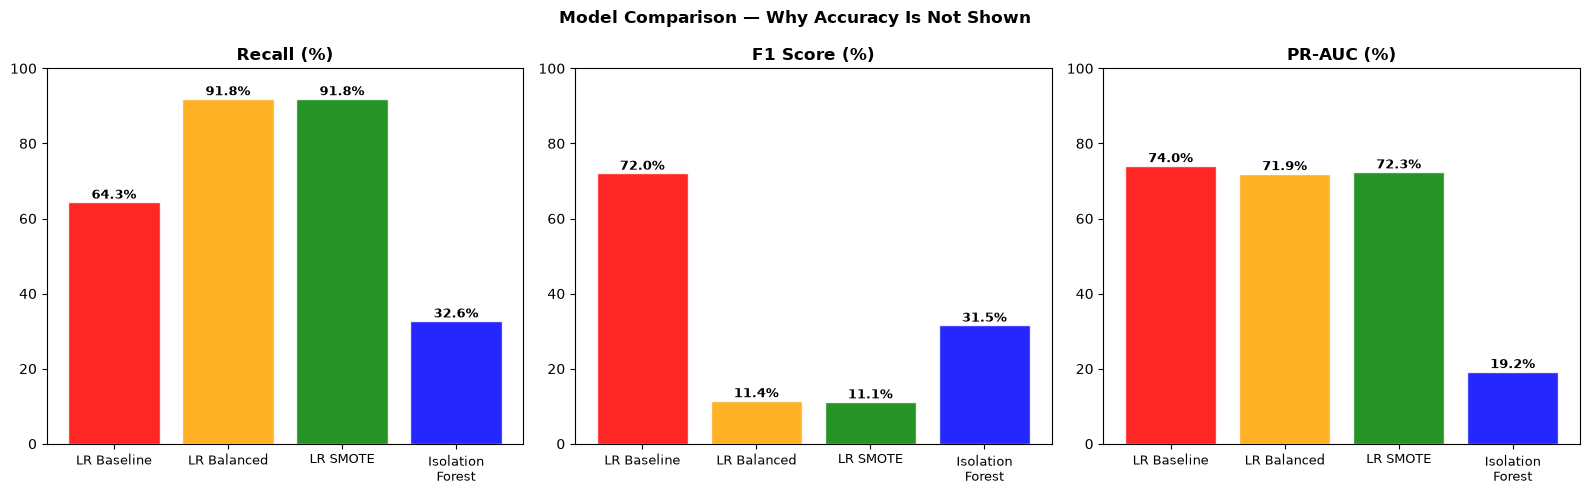

 Model comparison chart saved


In [11]:
# Compile all results
all_results = pd.DataFrame([
    results_baseline,
    results_balanced,
    results_smote,
    results_iso
])

all_results = all_results.round(2)
print("\n" + "="*70)
print("MODEL COMPARISON TABLE")
print("="*70)
print(all_results[['model', 'accuracy', 'precision', 'recall', 'f1', 'pr_auc']].to_string(index=False))
print("="*70)
print("\n→ Accuracy is NOT the right metric — look at Recall and PR-AUC")
print(" SMOTE improves Recall significantly over baseline")
print(" Isolation Forest catches fraud with zero label information")

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['recall', 'f1', 'pr_auc']
titles  = ['Recall (%)', 'F1 Score (%)', 'PR-AUC (%)']
colors  = ['red', 'orange', 'green', 'blue']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    bars = axes[i].bar(
        range(len(all_results)), 
        all_results[metric],
        color=colors,
        alpha=0.85,
        edgecolor='white'
    )
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xticks(range(len(all_results)))
    axes[i].set_xticklabels(
        ['LR Baseline', 'LR Balanced', 'LR SMOTE', 'Isolation\nForest'],
        fontsize=9
    )
    axes[i].set_ylim(0, 100)
    for bar, val in zip(bars, all_results[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — Why Accuracy Is Not Shown',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Model comparison chart saved")

In [12]:
best_model = all_results.sort_values(
    'pr_auc',
    ascending=False)

print(best_model[['model','pr_auc']])

                                         model  pr_auc
0      Logistic Regression (Baseline — No Fix)   74.02
2                  Logistic Regression (SMOTE)   72.35
1  Logistic Regression (class_weight=balanced)   71.89
3              Isolation Forest (Unsupervised)   19.16


In [13]:
import joblib

# Save SMOTE training data for Day 4 XGBoost
joblib.dump((X_train_smote, y_train_smote), 
            'D:/Projects/fraud-detection-shap-aws/models/smote_train_data.pkl')

# Save test data
joblib.dump((X_test, y_test), 
            'D:/Projects/fraud-detection-shap-aws/models/test_data.pkl')

# Save baseline results for comparison
all_results.to_csv(
    'D:/Projects/fraud-detection-shap-aws/reports/model_comparison.csv',
    index=False
)

print(" SMOTE training data saved")
print(" Test data saved")
print(" Model comparison CSV saved")
print("\nDay 3 complete. Ready for Day 4 — XGBoost + SHAP")

 SMOTE training data saved
 Test data saved
 Model comparison CSV saved

Day 3 complete. Ready for Day 4 — XGBoost + SHAP
